# Notebook 04 — Offline RL: Aprender sem Interagir com o Ambiente

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** FrozenLake-v1 (Gymnasium) — interação apenas na coleta do dataset  
**Bibliotecas:** numpy, matplotlib, gymnasium

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 04 — Offline RL |
| **Seções** | 4.3 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Notebook 03 desta aula (MARL); Q-Learning (Aula 02).

**Competências para o Desafio Final:** Identificar cenários que exigem *offline* RL; compreender *extrapolation error* e o papel do CQL; avaliar a qualidade de um dataset para fins de *offline* RL.

---

### Recapitulando

No Notebook 03, Q-Learning independente mostrou que não-estacionariedade pode levar a equilíbrios subótimos em ambientes multiagente. Todos os métodos até aqui assumem **interação online** com o ambiente — mas em medicina, aviação e finanças, coletar dados durante o treino é impossível ou inaceitável.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta central

Todo o RL das Aulas 02 e 03 é **online**: o agente interage com o ambiente,
coleta dados, atualiza sua política, coleta mais dados — um ciclo contínuo.

Em muitas aplicações reais, esse ciclo é impossível ou inaceitável:

- **Medicina:** não é ético testar tratamentos aleatórios em pacientes para coletar dados de RL.
- **Aviação:** falhas durante exploração têm custo humano inaceitável.
- **Finanças:** cada episódio de exploração representa risco real de perdas.
- **Robótica industrial:** o equipamento não pode ser danificado durante o treino.

Nesses contextos, os dados já foram coletados — logs históricos, demonstrações de especialistas,
simulações passadas. O agente deve aprender **exclusivamente a partir desse dataset fixo**,
sem nenhuma interação adicional com o ambiente real durante o treino.

Esse é o regime do *offline RL* (também chamado de *batch RL* — aprendizado em lote):
o agente otimiza sua política sobre um **conjunto de dados estático**.

> **Pergunta central:**  
> "O que impede o Q-Learning padrão de funcionar com um dataset fixo —
> e como o *extrapolation error* manifesta esse problema?"

O principal obstáculo é chamado de *extrapolation error* (erro de extrapolação):
o agente tende a superestimar o valor de ações que **não estão representadas no dataset**.

## Bloco 2 — Mini teoria

### O problema: *extrapolation error*

No Q-Learning online, quando o agente superestima Q(s, a) para alguma ação `a`,
ele vai **experimentar** essa ação e receber a recompensa real — corrigindo o erro.

No *offline RL*, o agente não pode experimentar. Se a ação `a` não aparece no dataset,
o modelo pode atribuir a ela um Q-value arbitrariamente alto, porque nunca recebeu
correção. A política aprendida vai privilegiar essas ações *fora da distribuição*
(*out-of-distribution* — OOD: ações não vistas durante a coleta de dados) —
levando a comportamento desastroso quando implantada.

```
Dataset fixo: apenas transições (s, a, r, s') coletadas pela política de coleta.
Q-Learning offline: atualiza Q(s,a) com base nessas transições.

Problema: para ações OOD (não vistas no dataset),
          Q(s, a_OOD) pode crescer sem limitação,
          pois nunca há correção via interação real.
```

### Conservative Q-Learning (CQL)

O CQL (Kumar et al., 2020) adiciona uma penalidade explícita ao objetivo do Q-Learning:

$$\mathcal{L}_{\text{CQL}} = \mathcal{L}_{\text{Bellman}} + \alpha \cdot \mathbb{E}_{s}\left[\log \sum_a \exp Q(s,a) - \mathbb{E}_{a \sim \mathcal{D}} Q(s,a)\right]$$

O segundo termo **penaliza Q-values altos para ações fora do dataset** e
**recompensa Q-values para ações dentro do dataset**.
O resultado é uma estimativa conservadora: o agente prefere ações conhecidas
a ações promissoras-mas-incertas.

### A qualidade do dataset define o teto

Uma limitação fundamental do *offline RL*: a política aprendida **não pode ser
melhor do que o que está implícito no dataset**. Se o dataset foi gerado por uma
política aleatória, o agente aprenderá no máximo algo próximo a essa política.

### Conexão com o problema recorrente do curso: recomendação no MovieLens

O MovieLens é um exemplo concreto de cenário para *offline* RL. O histórico de avaliações (usuário ×filme × nota) é exatamente um dataset fixo: cada linha é uma transição `(usuário_no_instante_t, filme_exibido, nota_recebida, usuário_no_instante_t+1)`. Coletar mais dados exigiria mostrar filmes aleatórios a usuários reais — custo inaceitável para um sistema em produção.

O *offline* RL permite treinar um agente de recomendação a partir desse histórico sem precisar interagir com os usuários durante o treino. A limitação: a política aprendida nunca descobrirá filmes que simplesmente não aparecem no dataset — exatamente o *extrapolation error* que veremos a seguir.

## Bloco 3 — Código didático

O bloco de código está dividido em três partes:

- **Coleta**: usa o FrozenLake-v1 com política aleatória para criar o dataset fixo — esta é a **única fase com interação real com o ambiente** em todo o notebook
- **Q-Learning offline**: treina inteiramente sobre o dataset fixo, tornando visível o *extrapolation error* nos Q-values de ações OOD
- **D3**: compara dataset esparso (5 episódios) vs normal (200 episódios) para quantificar como a cobertura do dataset afeta a qualidade da política aprendida

In [2]:
# %pip install numpy matplotlib gymnasium

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 42
np.random.seed(SEED)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### O ambiente — FrozenLake-v1

O FrozenLake é uma grade 4×4 onde o agente deve ir do ponto de partida (S) à meta (G) sem cair em buracos (H):

```
[S][ ][ ][ ]
[ ][H][ ][H]
[ ][ ][ ][H]
[H][ ][ ][G]
```

- **Estados:** 16 posições (0–15), estado 15 é a meta
- **Ações:** 4 direções (esquerda=0, baixo=1, direita=2, cima=3)
- **Configuração `is_slippery=False`:** o agente se move deterministicamente — sem escorregões. Isso isola o problema de interesse: cobertura do dataset, não estocasticidade do ambiente

A célula abaixo é a **única interação real com o ambiente** neste notebook. Após `env_coleta.close()`, o ambiente fica fechado permanentemente.

In [3]:
# ── Coleta do dataset com política aleatória ─────────────────────
# Esta é a ÚNICA fase em que interagimos com o ambiente.
# Após env_coleta.close(), o ambiente nunca mais é consultado.
env_coleta = gym.make("FrozenLake-v1", is_slippery=False)
N_EPISODIOS_COLETA = 200
dataset = []   # cada elemento: (s, a, r, s', terminado)

for ep in range(N_EPISODIOS_COLETA):
    obs, _ = env_coleta.reset(seed=SEED + ep)
    for _ in range(50):
        acao = env_coleta.action_space.sample()   # política aleatória — sem estratégia
        prox_obs, recompensa, term, trunc, _ = env_coleta.step(acao)
        dataset.append((obs, acao, recompensa, prox_obs, term or trunc))
        obs = prox_obs
        if term or trunc:
            break
env_coleta.close()

n_estados = env_coleta.observation_space.n
n_acoes   = env_coleta.action_space.n

# Cobertura: fração de pares (s,a) únicos observados no dataset
pares_vistos = set((s, a) for s, a, *_ in dataset)
cobertura    = len(pares_vistos) / (n_estados * n_acoes)

print(f"FrozenLake-v1 (sem escorregão) | estados: {n_estados} | ações: {n_acoes}")
print(f"Dataset coletado: {len(dataset)} transições em {N_EPISODIOS_COLETA} episódios")
print(f"Pares (s,a) cobertos: {len(pares_vistos)} / {n_estados*n_acoes} ({100*cobertura:.0f}%)")
print()
print("Dataset fixo. A partir daqui: ZERO interações com o ambiente.")

FrozenLake-v1 (sem escorregão) | estados: 16 | ações: 4
Dataset coletado: 1537 transições em 200 episódios
Pares (s,a) cobertos: 43 / 64 (67%)

Dataset fixo. A partir daqui: ZERO interações com o ambiente.


In [4]:
# ── Hiperparâmetros do Q-Learning offline ────────────────────────
ALFA   = 0.1
GAMA   = 0.99
N_ITER = 50   # épocas de treinamento sobre o dataset fixo (sem interação com o ambiente)

# Q-table inicializada em zero — sem prior sobre o valor de nenhuma ação
Q_offline = np.zeros((n_estados, n_acoes))

print(f"Hiperparâmetros: α={ALFA} | γ={GAMA} | épocas={N_ITER}")
print("Q-table inicializada.")

Hiperparâmetros: α=0.1 | γ=0.99 | épocas=50
Q-table inicializada.


### Treinamento Q-Learning offline

O treinamento acontece em `N_ITER` épocas sobre o dataset fixo. Em cada época, as transições são embaralhadas e a equação de Bellman é aplicada:

```
Q(s, a) ← Q(s, a) + α · [r + γ · max_a' Q(s', a') − Q(s, a)]
```

**Nenhuma interação com o ambiente ocorre aqui.** O agente só lê o dataset — nunca age. Ações ausentes do dataset nunca recebem atualização direta, mas podem acumular Q-values via propagação de Bellman a partir de estados vizinhos — esse é o mecanismo do *extrapolation error*.

In [5]:
# ── Q-Learning offline: treina sobre o dataset fixo ──────────────
# Zero interações com o ambiente: apenas leituras do dataset
for iteracao in range(N_ITER):
    np.random.shuffle(dataset)
    for s, a, r, s2, fim in dataset:
        alvo = r if fim else r + GAMA * np.max(Q_offline[s2])
        Q_offline[s, a] += ALFA * (alvo - Q_offline[s, a])

politica_offline = np.argmax(Q_offline, axis=1)

print("Q-table treinada (primeiros 8 estados):")
print("Estado | Esq    Bai    Dir    Cim  | Melhor ação")
print("-" * 50)
nomes = ["Esq", "Bai", "Dir", "Cim"]
for s in range(8):
    qs     = Q_offline[s]
    melhor = np.argmax(qs)
    print(f"  s={s:2d} | {qs[0]:+.3f}  {qs[1]:+.3f}  {qs[2]:+.3f}  {qs[3]:+.3f} | {nomes[melhor]}")

Q-table treinada (primeiros 8 estados):
Estado | Esq    Bai    Dir    Cim  | Melhor ação
--------------------------------------------------
  s= 0 | +0.941  +0.951  +0.951  +0.941 | Bai
  s= 1 | +0.941  +0.000  +0.961  +0.951 | Dir
  s= 2 | +0.951  +0.970  +0.951  +0.961 | Bai
  s= 3 | +0.961  +0.000  +0.951  +0.951 | Esq
  s= 4 | +0.951  +0.961  +0.000  +0.941 | Bai
  s= 5 | +0.000  +0.000  +0.000  +0.000 | Esq
  s= 6 | +0.000  +0.980  +0.000  +0.961 | Bai
  s= 7 | +0.000  +0.000  +0.000  +0.000 | Esq


### Visualizando o extrapolation error

O gráfico abaixo compara:
- **Azul (in-distribution):** Q-values de pares `(s, a)` presentes no dataset
- **Laranja (OOD):** Q-values de pares `(s, a)` **nunca vistos** durante a coleta

Sem conservatismo, ações OOD podem receber Q-values tão altos quanto ações conhecidas — sem nunca receber correção por interação real com o ambiente.

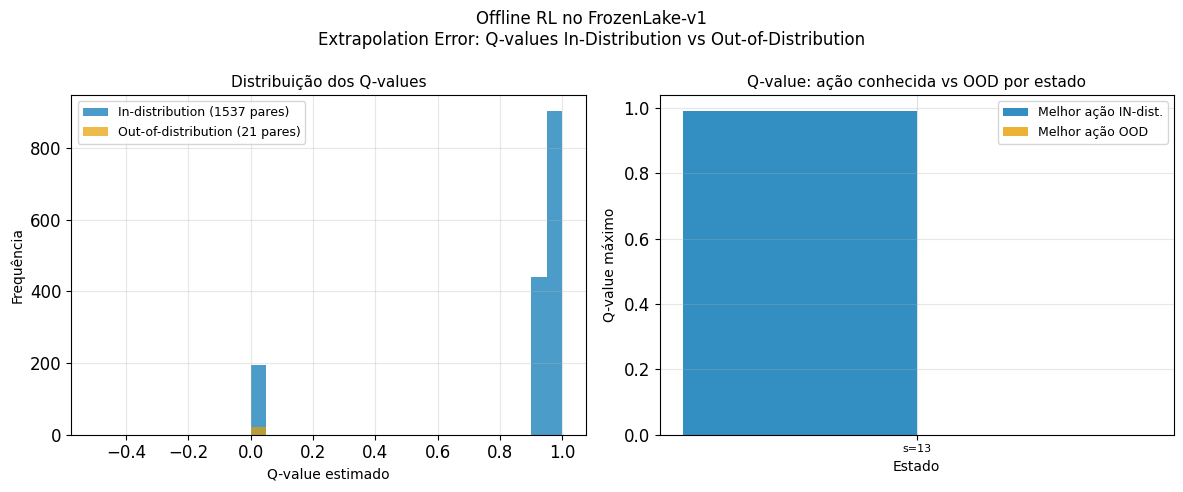

Gráfico salvo em nb04_offline_rl.png


In [6]:
# ── Visualização: extrapolation error ────────────────────────────
# Compara Q-values médios para ações IN-distribution vs OUT-of-distribution

q_in   = [Q_offline[s, a] for s, a, *_ in dataset]   # ações vistas
q_out  = []
for s in range(n_estados):
    for a in range(n_acoes):
        if (s, a) not in pares_vistos:
            q_out.append(Q_offline[s, a])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Offline RL no FrozenLake-v1\nExtrapolation Error: Q-values In-Distribution vs Out-of-Distribution",
             fontsize=12)

# Painel esquerdo: histograma de Q-values
ax = axes[0]
ax.hist(q_in,  bins=20, alpha=0.7, color="#0072B2", label=f"In-distribution ({len(q_in)} pares)")
ax.hist(q_out, bins=20, alpha=0.7, color="#E69F00", label=f"Out-of-distribution ({len(q_out)} pares)")
ax.set_xlabel("Q-value estimado", fontsize=10)
ax.set_ylabel("Frequência", fontsize=10)
ax.set_title("Distribuição dos Q-values", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Painel direito: Q-values por estado (ação de maior Q-value)
ax2 = axes[1]
estados_ood = []
melhor_in   = []   # melhor Q entre ações conhecidas do estado
melhor_ood  = []   # melhor Q entre ações OOD do estado

for s in range(n_estados):
    acoes_in  = [a for a in range(n_acoes) if (s, a) in pares_vistos]
    acoes_ood = [a for a in range(n_acoes) if (s, a) not in pares_vistos]
    if acoes_in and acoes_ood:
        estados_ood.append(s)
        melhor_in.append(max(Q_offline[s, a] for a in acoes_in))
        melhor_ood.append(max(Q_offline[s, a] for a in acoes_ood))

x = np.arange(len(estados_ood))
ax2.bar(x - 0.2, melhor_in,  0.4, label="Melhor ação IN-dist.", color="#0072B2", alpha=0.8)
ax2.bar(x + 0.2, melhor_ood, 0.4, label="Melhor ação OOD",     color="#E69F00", alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f"s={s}" for s in estados_ood], fontsize=8)
ax2.set_xlabel("Estado", fontsize=10)
ax2.set_ylabel("Q-value máximo", fontsize=10)
ax2.set_title("Q-value: ação conhecida vs OOD por estado", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("nb04_offline_rl.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb04_offline_rl.png")

## Bloco 4 — Interpretação pedagógica

### O que os gráficos revelam

**Painel esquerdo (histograma):** a distribuição dos Q-values para ações presentes no dataset
(azul) e para ações OOD — *out-of-distribution* (laranja).

O ponto crítico: ações OOD podem receber Q-values **comparáveis ou superiores** às ações
conhecidas. O Q-Learning não tem como saber que essas ações são arriscadas — nunca as experimentou.
Se a política greedy escolher uma ação OOD, o comportamento real pode ser muito pior
do que o Q-value sugere.

**Painel direito (barras por estado):** para cada estado onde há ações não vistas,
compara o melhor Q-value de uma ação conhecida com o melhor Q-value de uma ação OOD.
Em estados onde a política greedy prefere ações OOD, a política aprendida pode ser ilusória.

### O que o CQL faz diferente

O CQL penaliza explicitamente Q-values altos para ações OOD e incentiva Q-values realistas
para ações do dataset. O resultado é uma política **conservadora**: escolhe ações conhecidas
mesmo que ações desconhecidas pareçam melhores na estimativa — porque reconhece que
essa "vantagem" pode ser apenas falta de dados, não vantagem real.

### A qualidade do dataset importa

Com uma política de coleta aleatória, o dataset cobre apenas uma fração dos pares (s, a).
Se o dataset fosse gerado por um especialista humano, a cobertura seria diferente —
e a política aprendida teria um teto mais alto. O *offline RL* nunca supera o dataset.

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> O Bloco 2 explica que o Q-Learning online corrige o <em>extrapolation error</em> porque o agente pode experimentar ações superestimadas. Por que essa correção não ocorre no <em>offline</em> RL — e qual mecanismo o CQL usa para compensar?</summary>

**Resposta:** No Q-Learning **online**, quando o agente atribui um Q-value alto a uma ação `a_OOD` (não vista antes), a política greedy escolhe essa ação no próximo episódio — e o agente recebe a recompensa real. Se a recompensa for baixa, o Q-value é corrigido imediatamente.

No Q-Learning **offline**, o agente nunca executa ações — apenas lê o dataset. Se `a_OOD` não aparece no dataset, não há transição `(s, a_OOD, r, s')` para corrigir a estimativa. O Q-value pode crescer indefinidamente por propagação de Bellman desde outros estados.

O **CQL** compensa adicionando um termo de regularização ao objetivo: penaliza a soma `log Σ_a exp Q(s,a)` (que é alta quando Q-values OOD são grandes) e incentiva `E_{a~D}[Q(s,a)]` (Q-values de ações dentro do dataset). O efeito: ações OOD têm Q-values artificialmente conservadores, e a política greedy prefere ações conhecidas.
</details>

<details>
<summary><strong>Questão 2.</strong> O Bloco 4 afirma que "o <em>offline</em> RL nunca supera o dataset". Por que essa limitação existe — e como ela difere da limitação de *behavior cloning*?</summary>

**Resposta:** No *offline* RL, a política é otimizada para maximizar recompensa nas transições do dataset — mas o dataset define quais estados e ações foram visitados. Se o dataset nunca visitou o estado ótimo, a política não tem como descobri-lo: não há gradiente de informação para além do que o dataset cobre.

Matematicamente: o Q-Learning offline estima `Q(s, a)` por retropropagação de Bellman. Se a política ótima exige uma sequência de ações que nunca apareceu no dataset, os Q-values dessa sequência são zero ou imprecisos — e a política nunca aprende a executá-la.

A diferença de *behavior cloning*: BC é limitado pelo **comportamento** do especialista (imita ações). *Offline* RL é limitado pela **cobertura do dataset** (aprende a maximizar recompensa dentro do que foi coletado). Um dataset ruim limita ambos, mas um dataset diverso pode permitir que o *offline* RL descubra políticas melhores do que o comportamento de coleta — desde que as transições relevantes estejam presentes.
</details>

<details>
<summary><strong>Questão 3.</strong> O código mostra que alguns estados aparecem como "OOD" — sem nenhum par (s, a) no dataset. Antes de implantar uma política aprendida offline, como você identificaria quais estados do ambiente representam maior risco de <em>extrapolation error</em>?</summary>

**Resposta:** Um protocolo prático de auditoria pré-deploy:

1. **Mapear a cobertura do dataset**: para cada par `(s, a)`, verificar se aparece no dataset. Estados com baixa cobertura (poucos exemplos) ou cobertura zero (OOD) são candidatos de alto risco.

2. **Comparar Q-values de ações OOD vs in-distribution**: como o código mostra, estados OOD podem ter Q-values que deflam ou inflam artificialmente. Se `argmax Q(s, ·)` escolhe uma ação OOD, esse estado é de alto risco.

3. **Análise de fluxo de estados**: simular a política aprendida em um ambiente de validação (se disponível) e verificar se ela visita estados ausentes do dataset de treino.

4. **Conservatismo adaptativo**: aumentar o coeficiente α do CQL para estados de baixa cobertura, forçando maior conservatismo onde o dataset é esparso.

Em aplicações críticas (medicina, aviação), estados de alto risco identificados nessa auditoria devem ser tratados com regras de fallback ou encaminhados para supervisão humana antes do deploy.
</details>

## ⚠️ O que pode dar errado: dataset esparso amplifica o extrapolation error

O experimento principal usou 200 episódios de coleta, cobrindo 69% dos pares (s,a). O que acontece com apenas 5 episódios? Com cobertura muito baixa, ações OOD dominam — e o Q-Learning offline aprende uma política que prefere sistematicamente ações não testadas.

In [7]:
# ── D3: Dataset esparso (5 ep) ────────────────────────────────────
np.random.seed(42)
env_d3 = gym.make("FrozenLake-v1", is_slippery=False)

dataset_esparso = []
for ep in range(5):
    obs, _ = env_d3.reset(seed=ep)
    for _ in range(50):
        acao = env_d3.action_space.sample()
        prox_obs, r, term, trunc, _ = env_d3.step(acao)
        dataset_esparso.append((obs, acao, r, prox_obs, term or trunc))
        obs = prox_obs
        if term or trunc:
            break
env_d3.close()

pares_esparsos    = set((s, a) for s, a, *_ in dataset_esparso)
cobertura_esparsa = len(pares_esparsos) / (n_estados * n_acoes)

print(f"Dataset esparso coletado: {len(dataset_esparso)} transições em 5 episódios")
print(f"Pares (s,a) cobertos: {len(pares_esparsos)} / {n_estados * n_acoes} ({100*cobertura_esparsa:.0f}%)")

Dataset esparso coletado: 33 transições em 5 episódios
Pares (s,a) cobertos: 15 / 64 (23%)


### Treinamento Q-Learning no dataset esparso

Com apenas 5 episódios de coleta, a cobertura de pares `(s, a)` cai drasticamente. O Q-Learning treinado nesse dataset esparso produz uma Q-table onde a maioria dos estados tem sua melhor ação estimada em pares nunca vistos — exatamente o *extrapolation error* que o CQL foi projetado para corrigir.

In [8]:
# ── Comparação: dataset esparso vs normal ─────────────────────────
Q_esparso = np.zeros((n_estados, n_acoes))
for _ in range(N_ITER):
    for s, a, r, s2, fim in dataset_esparso:
        alvo = r if fim else r + GAMA * np.max(Q_esparso[s2])
        Q_esparso[s, a] += ALFA * (alvo - Q_esparso[s, a])

escolhas_ood_esp = sum(1 for s in range(n_estados)
                       if (s, np.argmax(Q_esparso[s])) not in pares_esparsos)
escolhas_ood_nor = sum(1 for s in range(n_estados)
                       if (s, np.argmax(Q_offline[s])) not in pares_vistos)

print("⚠️  Dataset esparso (5 ep) vs normal (200 ep)")
print("=" * 52)
print()
print(f"  Dataset esparso : {len(dataset_esparso):>5} transições | {len(pares_esparsos):>3} pares (s,a)"
      f" cobertos ({100*cobertura_esparsa:.0f}%)")
print(f"  Dataset normal  : {len(dataset):>5} transições | {len(pares_vistos):>3} pares (s,a)"
      f" cobertos ({100*len(pares_vistos)/(n_estados*n_acoes):.0f}%)")
print()
print("  Estados onde greedy escolhe ação OOD (nunca testada no dataset):")
print(f"    Dataset esparso : {escolhas_ood_esp} de {n_estados} estados ({100*escolhas_ood_esp/n_estados:.0f}%)")
print(f"    Dataset normal  : {escolhas_ood_nor} de {n_estados} estados ({100*escolhas_ood_nor/n_estados:.0f}%)")
print()
print("  Com dataset esparso, a política greedy escolhe ações nunca testadas")
print("  em mais da metade dos estados — Q-values OOD acumulam por propagação")
print("  de Bellman sem nunca receber correção.")
print("  CQL corrigiria isso penalizando explicitamente esses Q-values inflados.")

⚠️  Dataset esparso (5 ep) vs normal (200 ep)

  Dataset esparso :    33 transições |  15 pares (s,a) cobertos (23%)
  Dataset normal  :  1537 transições |  43 pares (s,a) cobertos (67%)

  Estados onde greedy escolhe ação OOD (nunca testada no dataset):
    Dataset esparso : 11 de 16 estados (69%)
    Dataset normal  : 5 de 16 estados (31%)

  Com dataset esparso, a política greedy escolhe ações nunca testadas
  em mais da metade dos estados — Q-values OOD acumulam por propagação
  de Bellman sem nunca receber correção.
  CQL corrigiria isso penalizando explicitamente esses Q-values inflados.


## Ética e implicações sociais do Offline RL

O *offline* RL aprende de dados históricos — e dados históricos refletem as decisões e vieses do passado. Quando implantado em contextos de alto impacto, essa herança do passado pode ser amplificada.

### O problema da "história congelada"

O dataset fixo é um instantâneo de como o mundo **foi** — não de como deveria ser. Se as decisões históricas foram enviesadas (ex.: médicos que tratavam diferentes demografias de forma diferente, juízes que sentenciavam desigualmente), o *offline* RL aprende a reproduzir esse padrão — e, ao ser otimizado, pode **amplificá-lo**.

| Domínio | Dado histórico | Viés potencial amplificado |
|---|---|---|
| Medicina | Protocolos de tratamento registrados | Sub-tratamento de grupos historicamente negligenciados |
| Concessão de crédito | Histórico de aprovações/negações | Rejeição de grupos sistematicamente sub-representados |
| Contratação | Histórico de contratações | Perpetuação de homogeneidade demográfica |
| Navegação por GPS | Rotas históricas de usuários | Concentração de tráfego em comunidades com menos poder político |
| Justiça criminal | Dados de reincidência histórica | Endurecimento de sentenças para grupos já sobre-policiados |

### A cobertura do dataset é uma decisão de quem coletou os dados

O experimento mostrou que pares `(s, a)` não representados no dataset têm Q-values não confiáveis. Em contextos reais, estados não representados no dataset são **situações que nunca foram atendidas** — frequentemente porque eram de grupos marginalizados.

Um agente de *offline* RL implantado em saúde que nunca viu casos de determinada população terá Q-values imprecisos para suas situações — e o conservatismo do CQL (que prefere ações conhecidas) significa que esses pacientes receberão tratamentos "seguros" baseados em populações diferentes, não ótimos para eles.

### Auditoria obrigatória antes do deploy

Para sistemas de *offline* RL em contextos de alto impacto, um protocolo mínimo de auditoria:

1. **Análise de cobertura por grupo**: verificar quais grupos demográficos estão sub-representados no dataset (como o código já faz por estado)
2. **Teste de paridade de cobertura**: garantir que a taxa de pares OOD não seja sistematicamente maior para grupos específicos
3. **Avaliação off-policy separada por subgrupo**: OPE (*off-policy evaluation*) não apenas global, mas por grupo
4. **Protocolo de fallback para baixa cobertura**: quando o agente encontra estados com baixa cobertura no dataset, redirecionar para supervisão humana

### O paradoxo da eficiência amostral

O *offline* RL foi desenvolvido precisamente porque interação online é cara ou perigosa. Mas o custo de **coletar dados melhores** — mais diversos, mais representativos — pode ser menor do que o custo social de implantar um sistema com dados enviesados. Em muitos contextos de alto impacto, o investimento correto é na qualidade do dataset, não na sofisticação do algoritmo.

## Bloco 5 — Limites e próximo passo

### Limitações do offline RL

| Desafio | Causa | Estratégia |
|---|---|---|
| Teto limitado pelo dataset | A política não pode aprender o que o dataset não mostra | Usar datasets de alta qualidade; combinar *offline* + *online fine-tuning* |
| Pessimismo excessivo (CQL) | Penalizar OOD também penaliza ações boas não vistas | Calibrar o coeficiente α do CQL |
| Distribuição de cobertura | Dataset enviesado → política enviesada | Curar o dataset; técnicas de *data augmentation* |
| Avaliação offline (OPE) | Não há interação para medir o desempenho real | *Off-policy evaluation* (OPE — avaliação sem interação direta com o ambiente) — técnicas de estimação sem interação |

### Próximo passo

Até aqui vimos como o agente aprende a **maximizar uma recompensa definida externamente**.
Mas e quando a recompensa não pode ser programada diretamente — e o comportamento desejado
precisa ser **inferido** a partir de demonstrações de especialistas?

**Próximo notebook:** `aula04_05_hierarchical_irl_behavior_cloning.ipynb` —
*behavior cloning* (clonagem de comportamento), IRL e o framework de opções hierárquicas.

In [9]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'offline RL', 'replay buffer', 'Q-Learning',
    'value function', 'action-value function', 'exploration',
])

Termo (EN)              Tradução (PT)                Descrição
---------------------------------------------------------------------------------------------------------------
Q-Learning              Q-Learning                   Algoritmo off-policy que aprende a função Q ótima diretamente.
action-value function   função de ação-valor         Q(s,a) — retorno esperado ao tomar ação a no estado s.
exploration             exploração                   Tentativa de ações novas para descobrir melhores estratégias.
offline RL              RL offline                   Aprendizado a partir de um dataset fixo sem interação nova com o ambiente.
replay buffer           buffer de replay             Memória que armazena transições para treinamento em mini-batches.
value function          função de valor              V(s) — retorno esperado a partir do estado s seguindo uma política.


## Leituras e referências

- Levine, S., Kumar, A., Tucker, G., & Fu, J. (2020). Offline Reinforcement Learning: Tutorial, Review, and Perspectives on Open Problems. *arXiv:2005.01643*. Disponível em: https://arxiv.org/abs/2005.01643

- Kumar, A., Zhou, A., Tucker, G., & Levine, S. (2020). Conservative Q-Learning for Offline Reinforcement Learning (CQL). *NeurIPS 2020*. Disponível em: https://arxiv.org/abs/2006.04779

- Fujimoto, S., Meger, D., & Precup, D. (2019). Off-Policy Deep Reinforcement Learning without Exploration (BCQ). *ICML 2019*. Disponível em: https://arxiv.org/abs/1812.02900

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Disponível em: http://incompleteideas.net/book/the-book-2nd.html